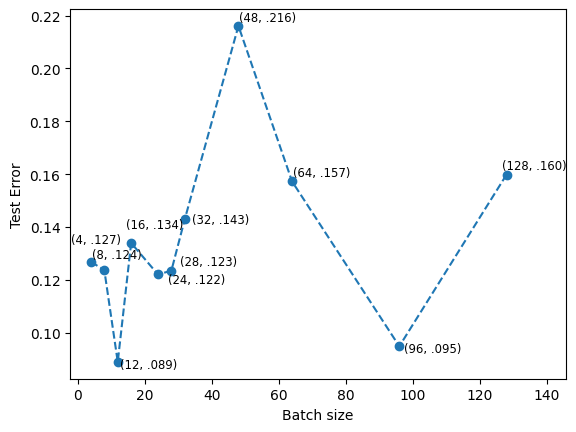

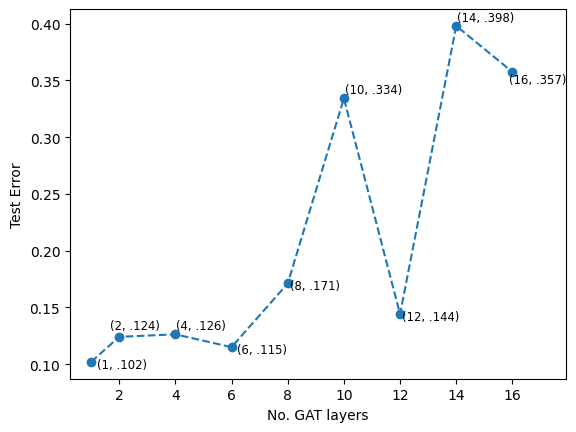

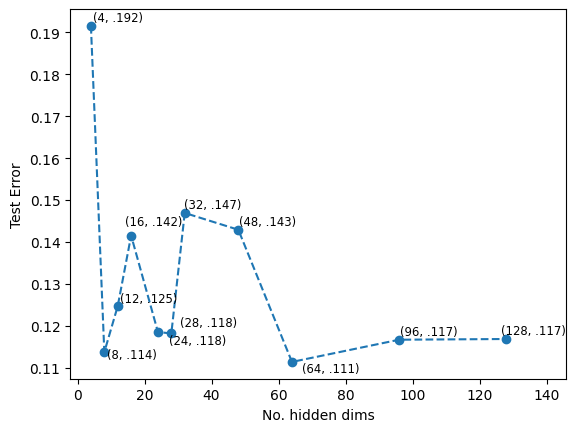

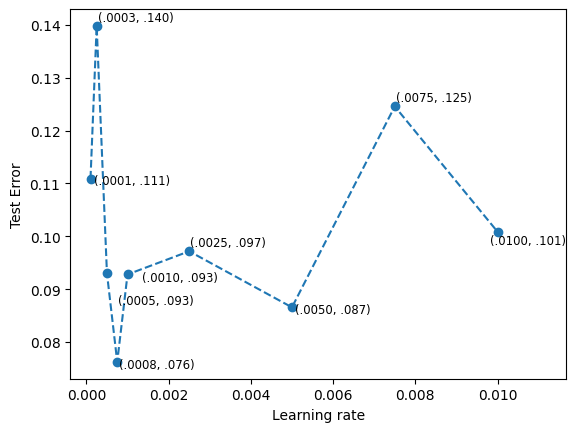

In [82]:
import matplotlib.pyplot as plt
import csv
from adjustText import adjust_text
import numpy as np

def csv_to_xy(filename: str):
    x, y = [], []
    with open(filename, 'r') as file:
        reader = csv.reader(file)
        for _x, _y in reader:
            x.append(float(_x))
            y.append(float(_y))
    return x, y


def create_plot(paramname, filename):
    x, y = csv_to_xy(filename)
    plt.figure()
    plt.plot(x, y, 'o--')
    #plt.title(f'Error rate vs. {paramname}')
    plt.xlabel(paramname)
    plt.ylabel('Test Error')

    fmt = '({:.4f}, {:.3f})' if x[0] < 1 else '({:.0f}, {:.3f})'
    labels = [ fmt.format(_x, _y).replace('0.', '.') for _x, _y in zip(x, y) ]
    texts = [ plt.text(_x, _y, _t, size='small') for _x, _y, _t in zip(x, y, labels) ]
    _x = np.linspace(min(x), max(x), 200)
    _y = np.interp(_x, x, y)
    adjust_text(texts, x=_x, y=_y, expand_axes=True)
    plt.savefig(filename.replace('.csv', '.png'))
    

create_plot('Batch size', 'sweeper-output/wns-batch-size-summary.csv')
create_plot('No. GAT layers', 'sweeper-output/wns-gat-layers-summary.csv')
create_plot('No. hidden dims', 'sweeper-output/wns-hidden-dim-summary.csv')
create_plot('Learning rate', 'sweeper-output/wns-learning-rate-summary.csv')